In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

rng = np.random.default_rng(seed=12345)

In [9]:
risk_levels = np.array([1, 2, 3, 4, 5])
expected_returns = np.array([0.10, 0.30, 0.50, 0.80, 1.20])
std_returns = np.array([0.05, 0.15, 0.30, 0.60, 1.00])
n_obs_per_level = np.array([400, 250, 120, 50, 20])

In [11]:
risk_list = []
ret_list = []

for i in range(len(risk_levels)):
    n_i = n_obs_per_level[i]
    actual_returns = rng.normal(loc=expected_returns[i],
                                 scale=std_returns[i],
                                 size=n_i)
    risk_list.extend([risk_levels[i]] * n_i)
    ret_list.extend(actual_returns)

df = pd.DataFrame({"risk": risk_list, "ret": ret_list})
print(df.shape)
df

(840, 2)


,risk,ret
0,1,0.092498
1,1,0.119495
2,1,0.045846
3,1,0.254274
4,1,0.160442
...,...,...
835,5,2.016017
836,5,1.029677
837,5,0.839009
838,5,0.986681


In [12]:
model_true = smf.ols("ret ~ risk", data=df).fit()
print(model_true.summary())

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     703.0
Date:                Tue, 07 Jul 2026   Prob (F-statistic):          5.79e-113
Time:                        15:23:07   Log-Likelihood:                -54.095
No. Observations:                 840   AIC:                             112.2
Df Residuals:                     838   BIC:                             121.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1387      0.018     -7.517      0.0

In [17]:
thresholds = {1: 0.05, 2: 0.15, 3: 0.30, 4: 0.50, 5: 0.80}

df["threshold"] = df["risk"].map(thresholds)
df["survives"] = df["ret"] > df["threshold"]

print(df.groupby("risk")["survives"].mean())

risk
1    0.875
2    0.864
3    0.775
4    0.680
5    0.750
Name: survives, dtype: float64


In [18]:
df_survivors = df[df["survives"]]
model_biased = smf.ols("ret ~ risk", data=df_survivors).fit()
print(model_biased.summary())


                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     1992.
Date:                Tue, 07 Jul 2026   Prob (F-statistic):          9.80e-208
Time:                        15:29:24   Log-Likelihood:                 201.39
No. Observations:                 708   AIC:                            -398.8
Df Residuals:                     706   BIC:                            -389.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2250      0.014    -15.765      0.0

In [19]:
print("True slope:  ", round(model_true.params["risk"], 3))
print("Biased slope:", round(model_biased.params["risk"], 3))
print("Bias:        ", round(model_biased.params["risk"] - model_true.params["risk"], 3))

True slope:   0.231
Biased slope: 0.311
Bias:         0.08


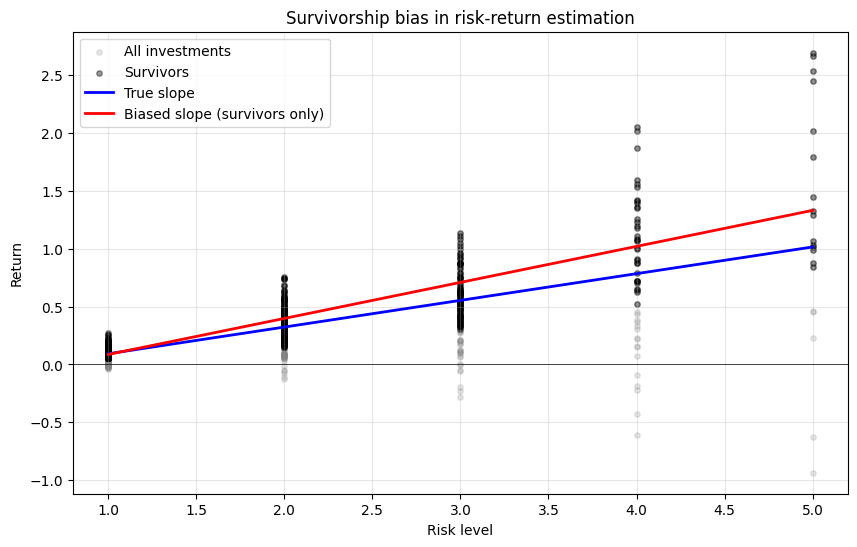

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df["risk"], df["ret"], alpha=0.2, color="grey", s=15, label="All investments")
ax.scatter(df_survivors["risk"], df_survivors["ret"], alpha=0.4, color="black", s=15, label="Survivors")

x_range = np.linspace(1, 5, 100)
y_true = model_true.params["Intercept"] + model_true.params["risk"] * x_range
y_biased = model_biased.params["Intercept"] + model_biased.params["risk"] * x_range

ax.plot(x_range, y_true, color="blue", linewidth=2, label="True slope")
ax.plot(x_range, y_biased, color="red", linewidth=2, label="Biased slope (survivors only)")

ax.set_xlabel("Risk level")
ax.set_ylabel("Return")
ax.set_title("Survivorship bias in risk-return estimation")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

,risk,return,threshold
0,1,0.028809,-0.05
1,1,0.163186,-0.05
2,1,0.056467,-0.05
3,1,0.087041,-0.05
4,1,0.096233,-0.05
...,...,...,...
835,5,2.874194,-0.50
836,5,2.143234,-0.50
837,5,0.758444,-0.50
838,5,2.674816,-0.50
